In [8]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 62.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 53.3 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [9]:
import random
import statistics

from typing import Dict, Optional
import matplotlib.pyplot as plt

## Default

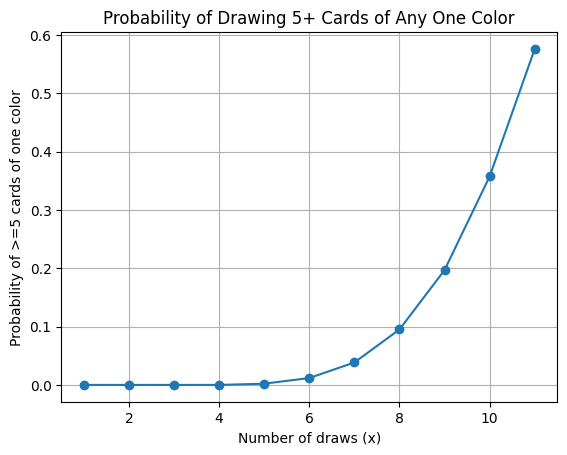

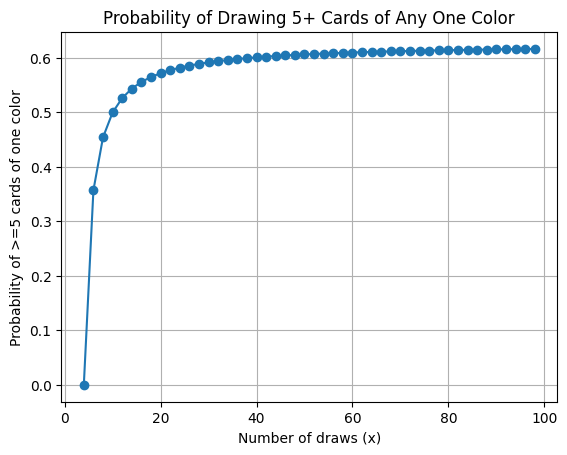

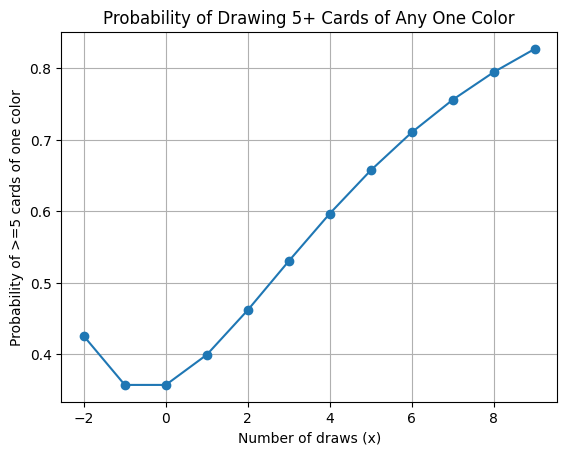

In [28]:
import math
import matplotlib.pyplot as plt

# Combination function
def comb(n, k):
    if k < 0 or k > n:
        return 0
    return math.comb(n, k)

# Probability that at least one color has >=5 cards
def prob_at_least_5(x, shift=0, num=6):
    total = comb(num * 3 + shift, x)
    favorable = 0

    # Iterate over all possible counts of the three colors
    # c1 + c2 + c3 = x
    for c1 in range(0, min(num + shift, x) + 1):
        for c2 in range(0, min(num, x - c1) + 1):
            c3 = x - c1 - c2
            if c3 < 0 or c3 > num:
                continue

            # Check if any color has at least 5
            if c1 >= 5 or c2 >= 5 or c3 >= 5:
                ways = comb(num + shift, c1) * comb(num, c2) * comb(num, c3)
                favorable += ways

    return favorable / total
#
# Draws
xs = list(range(1, 12))
probs = [prob_at_least_5(x) for x in xs]
plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel('Number of draws (x)')
plt.ylabel('Probability of >=5 cards of one color')
plt.title('Probability of Drawing 5+ Cards of Any One Color')
plt.grid(True)
plt.show()

# Num cards
xs = list(range(4, 100, 2))
probs = [prob_at_least_5(10, num=x) for x in xs]
plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel('Number of draws (x)')
plt.ylabel('Probability of >=5 cards of one color')
plt.title('Probability of Drawing 5+ Cards of Any One Color')
plt.grid(True)
plt.show()

# Num cards
xs = list(range(-2, 10, 1))
probs = [prob_at_least_5(10, num=6, shift=x) for x in xs]
plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel('Number of draws (x)')
plt.ylabel('Probability of >=5 cards of one color')
plt.title('Probability of Drawing 5+ Cards of Any One Color')
plt.grid(True)
plt.show()

## With Jokers

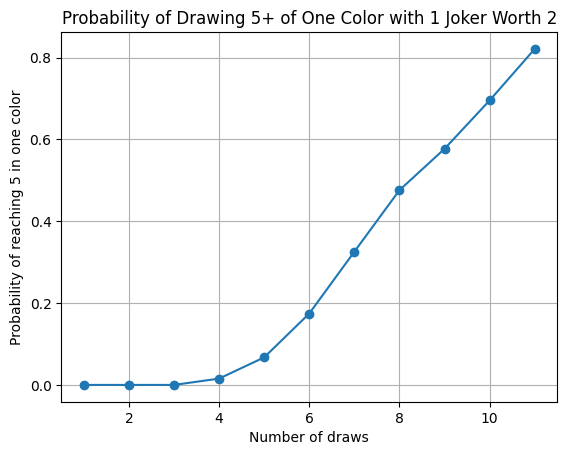

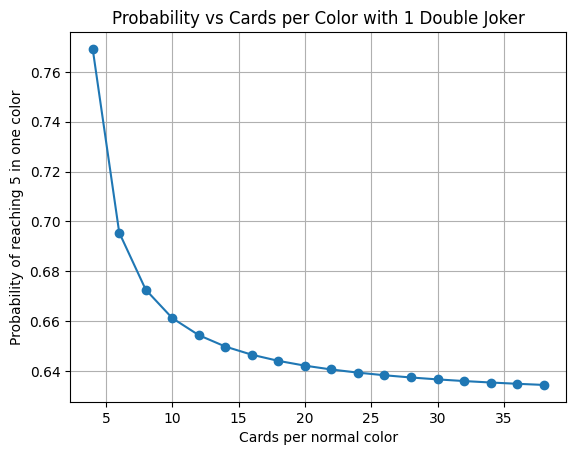

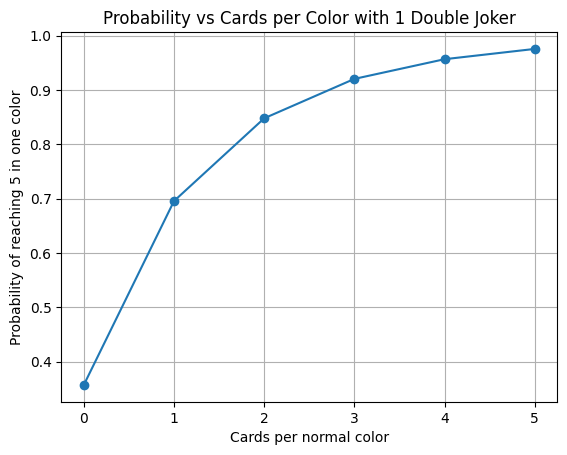

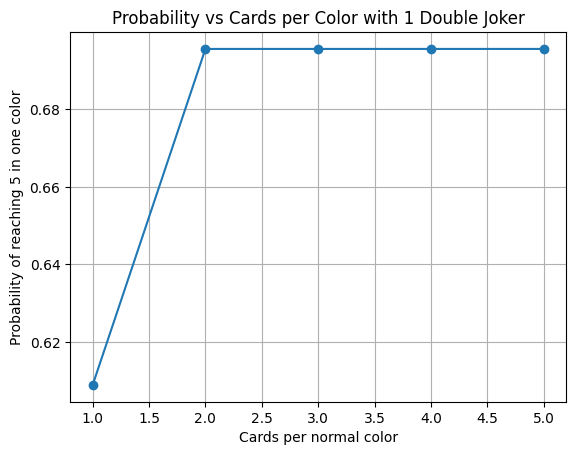

In [34]:
import math
import matplotlib.pyplot as plt

def comb(n, k):
    if k < 0 or k > n:
        return 0
    return math.comb(n, k)

def prob_at_least_5_with_double_joker(x, num=6, joker_num=1, joker_value=2):
    total_cards = 3 * num + joker_num
    if x < 0 or x > total_cards:
        return 0.0

    total = comb(total_cards, x)
    favorable = 0

    for c1 in range(0, min(num, x) + 1):
        for c2 in range(0, min(num, x - c1) + 1):
            for c3 in range(0, min(num, x - c1 - c2) + 1):
                j = x - c1 - c2 - c3
                if j < 0 or j > joker_num:
                    continue

                ways = comb(num, c1) * comb(num, c2) * comb(num, c3) * comb(joker_num, j)

                if max(c1, c2, c3) + joker_value * j >= 5:
                    favorable += ways

    return favorable / total

# Probability vs number of draws
xs = list(range(1, 12))
probs = [prob_at_least_5_with_double_joker(x, num=6, joker_num=1, joker_value=2) for x in xs]
plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel('Number of draws')
plt.ylabel('Probability of reaching 5 in one color')
plt.title('Probability of Drawing 5+ of One Color with 1 Joker Worth 2')
plt.grid(True)
plt.show()

# Probability vs cards per normal color
xs = list(range(4, 40, 2))
probs = [prob_at_least_5_with_double_joker(10, num=x, joker_num=1, joker_value=2) for x in xs]
plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel('Cards per normal color')
plt.ylabel('Probability of reaching 5 in one color')
plt.title('Probability vs Cards per Color with 1 Double Joker')
plt.grid(True)
plt.show()

# Probability vs cards per normal color
xs = list(range(0, 6, 1))
probs = [prob_at_least_5_with_double_joker(10, joker_num=x, joker_value=2) for x in xs]
plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel('Cards per normal color')
plt.ylabel('Probability of reaching 5 in one color')
plt.title('Probability vs Cards per Color with 1 Double Joker')
plt.grid(True)
plt.show()

# Probability vs cards per normal color
xs = list(range(1, 6, 1))
probs = [prob_at_least_5_with_double_joker(10, joker_num=1, joker_value=x) for x in xs]
plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel('Cards per normal color')
plt.ylabel('Probability of reaching 5 in one color')
plt.title('Probability vs Cards per Color with 1 Double Joker')
plt.grid(True)
plt.show()